# 03 - Who Is Actually Leaving?
## Customer Churn Insights

This notebook answers two practical questions for the retention team:

1. **Which kind of customer is most likely to churn?** (data-driven: real churn rates by segment)
2. **Which features does the model rely on most to make that call?** (model-driven: feature importance)

These are two different questions with two different answers, and it's worth keeping them separate:
a feature can have a high churn *rate* in the raw data without being very *important* to the trained model
(and vice versa), because the model weighs features against each other rather than in isolation.


In [1]:
# Add the src/ folder to the path so we can import our own churn_predictor package
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from churn_predictor.data import load_raw_data

# Load the raw dataset once - every analysis below reads from this same dataframe
df = load_raw_data()
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Churn rate by age group
First, bucket customers into age bands so we can compare churn rate group by group instead of customer by customer.

AgeGroup
18-29     7.6
30-39    10.9
40-49    30.8
50-59    56.0
60+      27.9
Name: Exited, dtype: float64


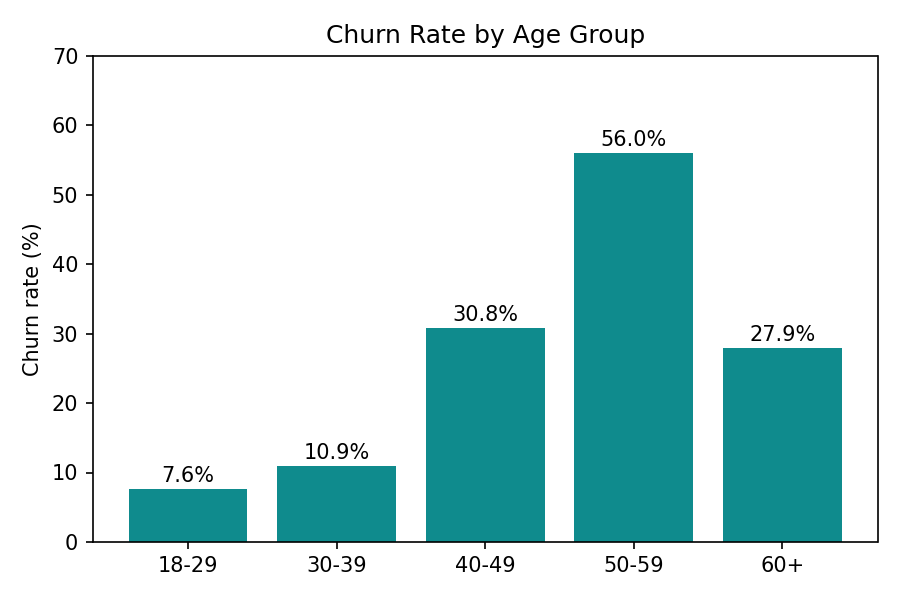

In [2]:
# Split customers into five age bands
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 29, 39, 49, 59, 100],
    labels=["18-29", "30-39", "40-49", "50-59", "60+"],
)

# Compute the churn rate (as a percentage) within each age band
age_churn_rate = df.groupby("AgeGroup")["Exited"].mean().mul(100).round(1)
print(age_churn_rate)

# Show the chart version of the same numbers
display(Image(filename="../reports/figures/churn_by_agegroup.png"))

**Finding:** churn rises sharply through middle age and peaks at **50-59 (56.0% churn)** — more than half of customers in that age band leave. It drops back down for 60+, which is worth flagging as a real pattern rather than smoothing it away: something about the 50s decade specifically is a risk window.

## 2. Churn rate by tenure, balance, and credit score
Do the same bucket-and-compare approach for three more account attributes.

Churn rate by tenure:
TenureGroup
0-2 yrs    21.2
3-5 yrs    20.8
6-8 yrs    18.9
9+ yrs     21.3
Name: Exited, dtype: float64


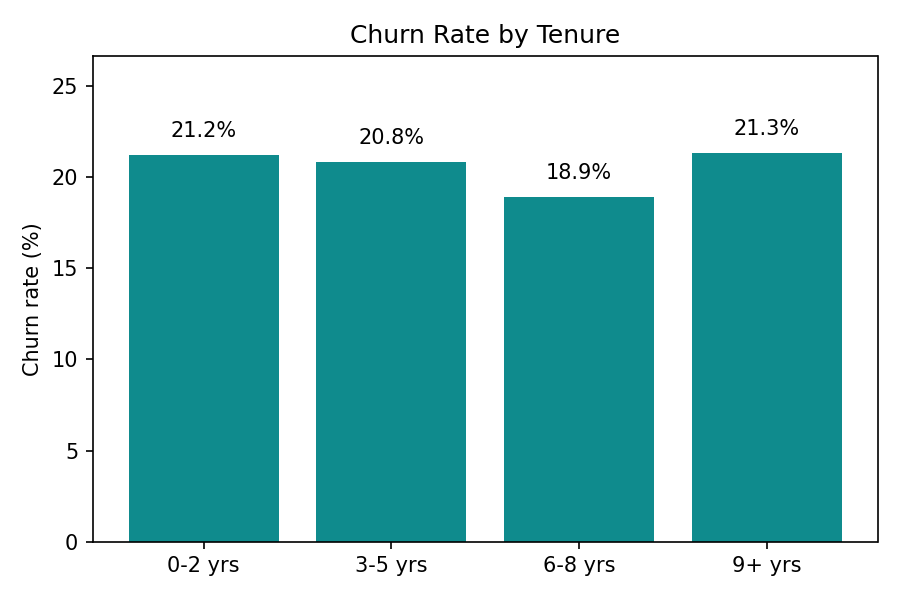

In [3]:
# Tenure: how many years the customer has held an account
df["TenureGroup"] = pd.cut(df["Tenure"], bins=[-1, 2, 5, 8, 20], labels=["0-2 yrs", "3-5 yrs", "6-8 yrs", "9+ yrs"])
tenure_churn_rate = df.groupby("TenureGroup")["Exited"].mean().mul(100).round(1)
print("Churn rate by tenure:")
print(tenure_churn_rate)
display(Image(filename="../reports/figures/churn_by_tenuregroup.png"))

Churn rate by balance:
BalanceGroup
Zero        13.8
$1-50k      34.7
$50-100k    19.9
$100k+      25.2
Name: Exited, dtype: float64


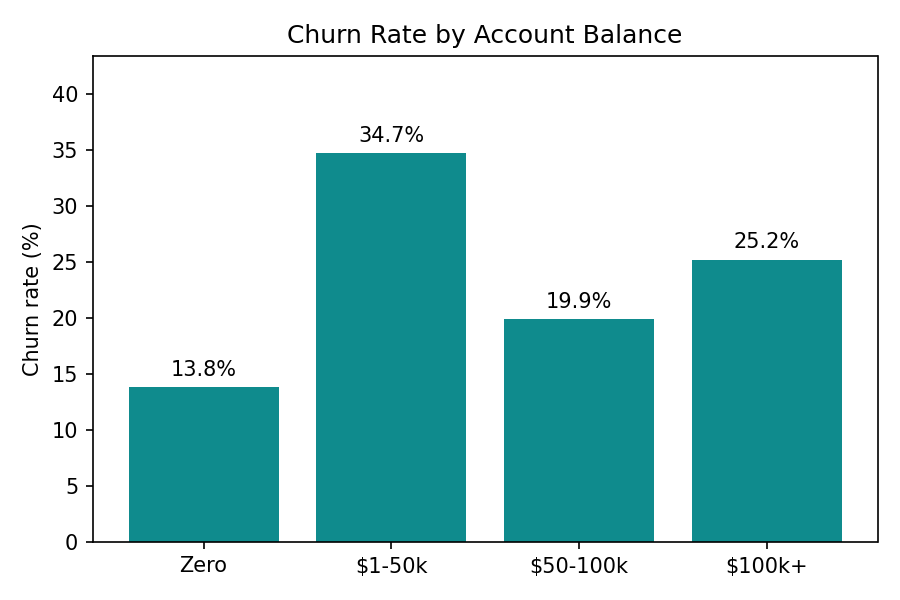

In [4]:
# Balance: how much money is in the account (zero balance is common and worth its own bucket)
df["BalanceGroup"] = pd.cut(
    df["Balance"], bins=[-1, 0, 50000, 100000, 100000000],
    labels=["Zero", "$1-50k", "$50-100k", "$100k+"],
)
balance_churn_rate = df.groupby("BalanceGroup")["Exited"].mean().mul(100).round(1)
print("Churn rate by balance:")
print(balance_churn_rate)
display(Image(filename="../reports/figures/churn_by_balancegroup.png"))

Churn rate by credit score band:
CreditBand
Poor (<580)         22.0
Fair (580-669)      20.6
Good (670-739)      18.6
Excellent (740+)    20.2
Name: Exited, dtype: float64


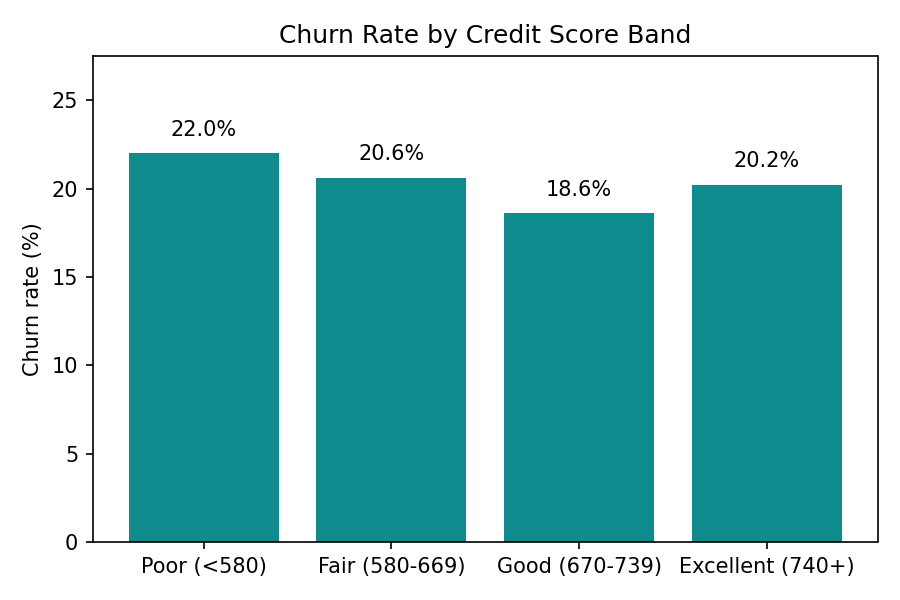

In [5]:
# Credit score: standard-ish industry bands (poor / fair / good / excellent)
df["CreditBand"] = pd.cut(
    df["CreditScore"], bins=[299, 579, 669, 739, 900],
    labels=["Poor (<580)", "Fair (580-669)", "Good (670-739)", "Excellent (740+)"],
)
credit_churn_rate = df.groupby("CreditBand")["Exited"].mean().mul(100).round(1)
print("Churn rate by credit score band:")
print(credit_churn_rate)
display(Image(filename="../reports/figures/churn_by_creditband.png"))

**Finding:** tenure (18.9-21.3%) and credit score band (18.6-22.0%) barely move the churn rate at all — neither is a useful signal on its own. Balance is more interesting and non-obvious: customers with a **small positive balance ($1-50k) churn the most (34.7%)**, more than customers with either a zero balance (13.8%, the lowest of any group) or a large balance ($100k+, 25.2%). A zero balance looks like it might signal disengagement, but it's actually associated with the *lowest* churn — a good example of why raw intuition needs to be checked against real numbers before acting on it.

## 3. Churn rate by activity and card ownership

Churn rate by activity status:
IsActiveMember
Active      14.3
Inactive    26.9
Name: Exited, dtype: float64


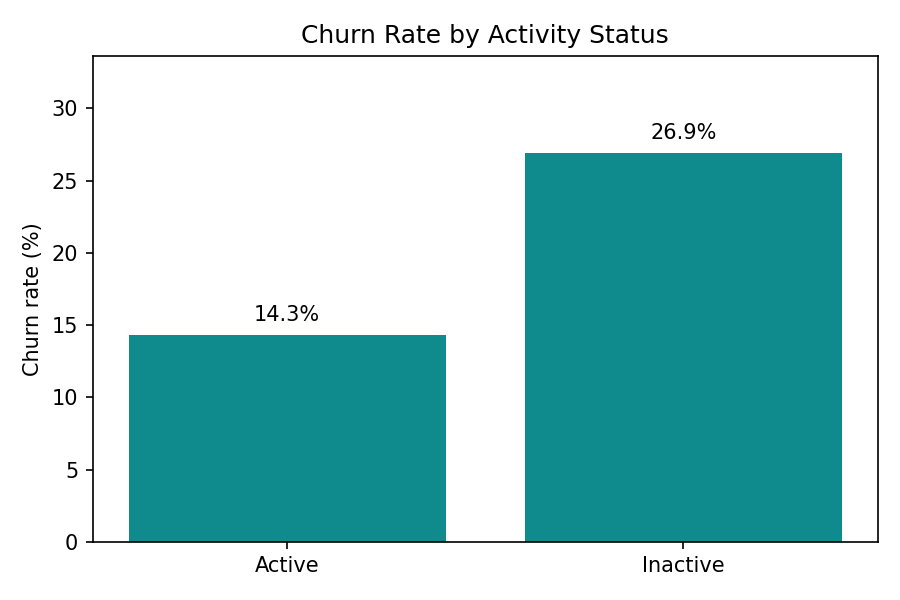

In [6]:
# Active membership: does the customer actually use the bank day-to-day?
activity_labels = df["IsActiveMember"].map({0: "Inactive", 1: "Active"})
activity_churn_rate = df.groupby(activity_labels)["Exited"].mean().mul(100).round(1)
print("Churn rate by activity status:")
print(activity_churn_rate)
display(Image(filename="../reports/figures/churn_by_activity.png"))

Churn rate by credit card ownership:
HasCrCard
Has Card    20.2
No Card     20.8
Name: Exited, dtype: float64


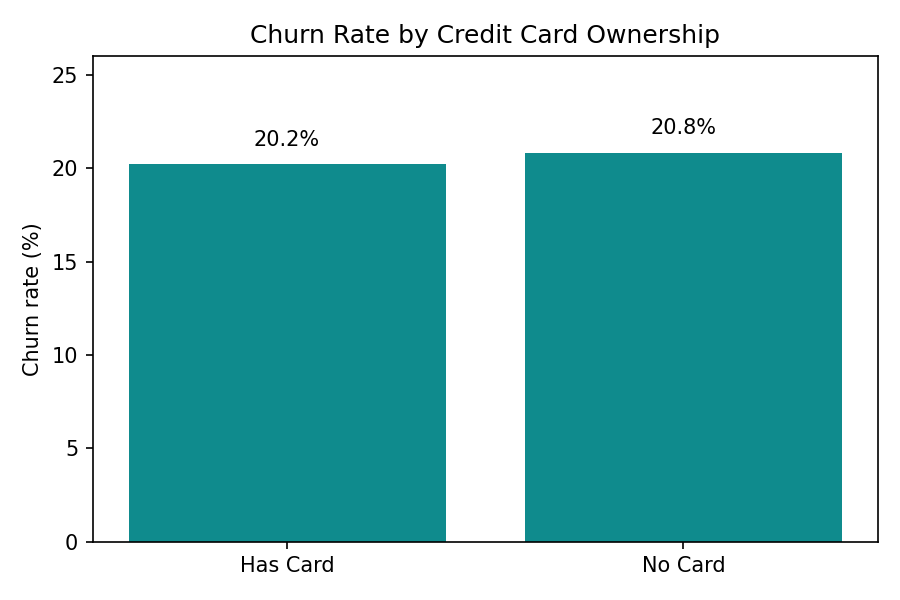

In [7]:
# Credit card ownership: a common assumption is that card holders are "stickier" customers
card_labels = df["HasCrCard"].map({0: "No Card", 1: "Has Card"})
card_churn_rate = df.groupby(card_labels)["Exited"].mean().mul(100).round(1)
print("Churn rate by credit card ownership:")
print(card_churn_rate)
display(Image(filename="../reports/figures/churn_by_card.png"))

**Finding:** activity status is a real, usable signal — inactive members churn at **26.9%** vs. **14.3%** for active ones, nearly double. Credit card ownership, by contrast, makes almost no difference (20.8% vs. 20.2%) despite being a common assumption in retention playbooks — worth retiring that assumption for this bank.

## 4. Who is over-represented among customers who actually left?
Compare each group's share of *all* customers against its share of *churned* customers. If a group leaves at the same rate as everyone else, the two bars should match.

Female share -> all customers: 45.4% | churned customers: 55.9%
Germany share -> all customers: 25.1% | churned customers: 40.0%
Inactive share -> all customers: 48.5% | churned customers: 63.9%


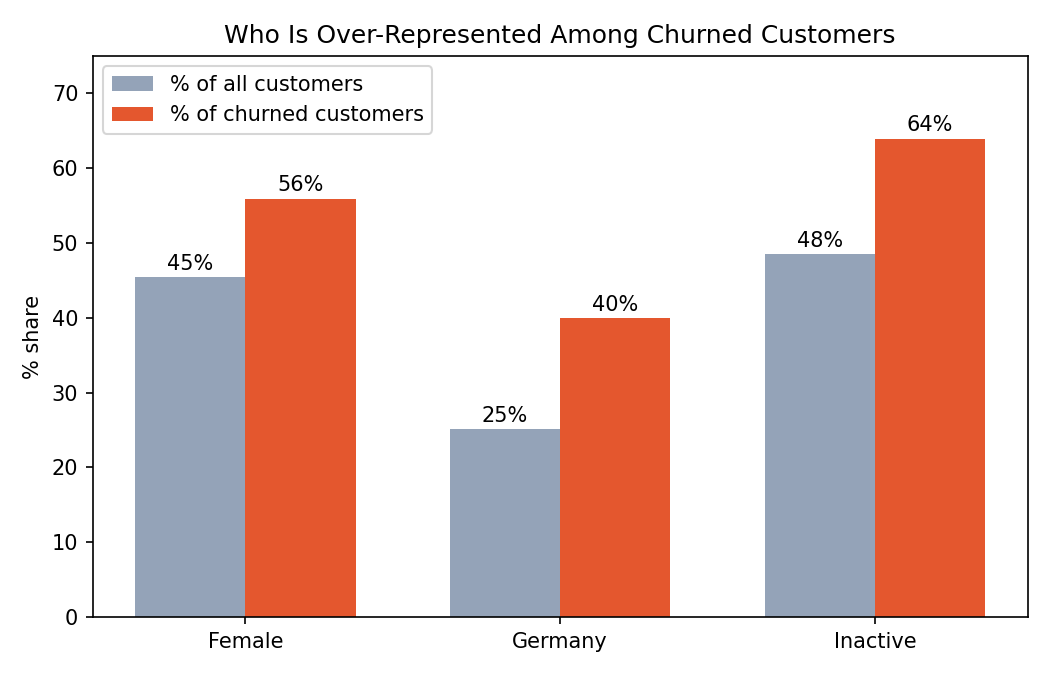

In [8]:
# For each group, compare "% of all customers" vs. "% of customers who churned"
# A big gap between the two bars means that group is over-represented among leavers
print("Female share -> all customers: {:.1f}% | churned customers: {:.1f}%".format(
    df["Gender"].eq("Female").mean() * 100,
    df[df.Exited == 1]["Gender"].eq("Female").mean() * 100,
))
print("Germany share -> all customers: {:.1f}% | churned customers: {:.1f}%".format(
    df["Geography"].eq("Germany").mean() * 100,
    df[df.Exited == 1]["Geography"].eq("Germany").mean() * 100,
))
print("Inactive share -> all customers: {:.1f}% | churned customers: {:.1f}%".format(
    df["IsActiveMember"].eq(0).mean() * 100,
    df[df.Exited == 1]["IsActiveMember"].eq(0).mean() * 100,
))

display(Image(filename="../reports/figures/churn_representation.png"))

**Finding:** Germany customers are the clearest case — they're only **25% of the customer base but 40% of everyone who churned**. Inactive members show the same pattern even more strongly (49% of customers, but 64% of churners). Female customers are moderately over-represented (45% of customers, 56% of churners).

## 5. Profile comparison: a customer who stays vs. a customer who leaves

                 Stayed (0)  Exited (1)
CreditScore           651.9       645.4
Age                    37.4        44.8
Tenure                  5.0         4.9
Balance             72745.3     91108.5
NumOfProducts           1.5         1.5
EstimatedSalary     99738.4    101465.7


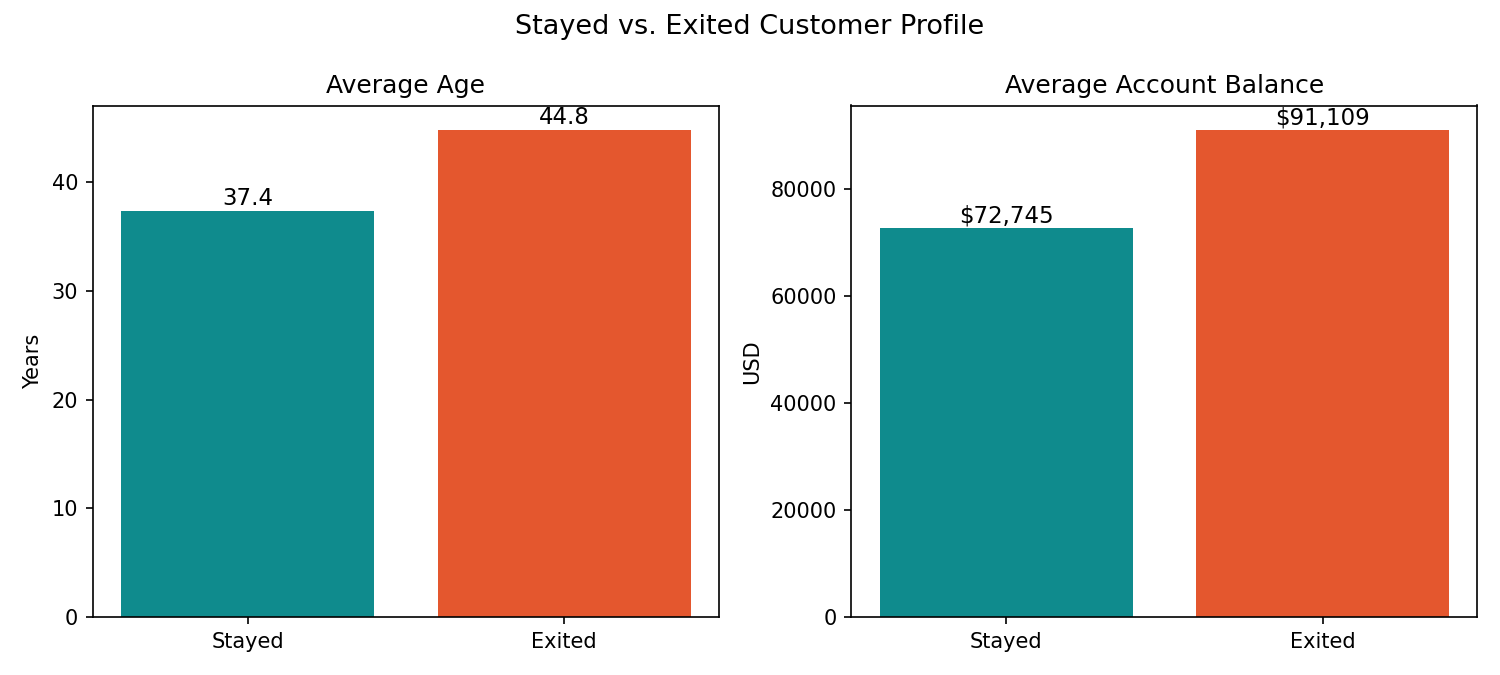

In [9]:
# Average out every numeric feature separately for "stayed" and "exited" customers
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
profile = df.groupby("Exited")[numeric_cols].mean().round(1).T
profile.columns = ["Stayed (0)", "Exited (1)"]
print(profile)

display(Image(filename="../reports/figures/profile_comparison.png"))

**Finding:** the two numbers that actually separate a typical leaver from a typical stayer are **age** (44.8 vs. 37.4 years — leavers are noticeably older) and **balance** (\$91,109 vs. \$72,745 — leavers hold more money in the account, which also makes them the more expensive customers to lose). Credit score, tenure, product count, and salary are nearly identical between the two groups — they don't help tell a leaver apart from a stayer.

## 6. Which features does the trained model actually rely on?
This is a different question from everything above: not "what does the raw data show", but "what did the Random Forest learn to pay attention to".

Age                   37.9%
NumOfProducts         23.1%
Balance                9.6%
IsActiveMember         6.4%
EstimatedSalary        5.1%
CreditScore            5.1%
Geography_Germany      4.8%
Tenure                 2.7%
Gender_Male            2.2%
Geography_France       1.5%
Geography_Spain        0.9%
HasCrCard              0.6%


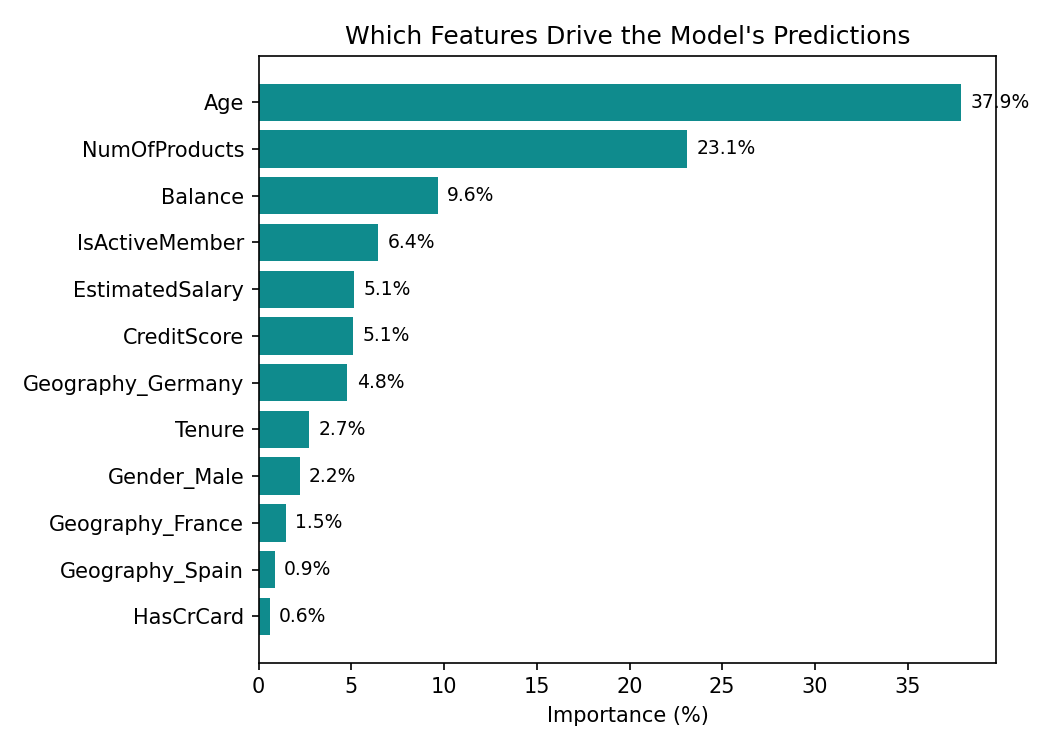

In [10]:
# Load the saved pipeline and pull the trained model's feature importances
import joblib

pipeline = joblib.load("../artifacts/churn_pipeline.joblib")
model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocess"]

feature_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

# Sort features from most to least important and print as a percentage
ranking = sorted(zip(feature_names, importances), key=lambda pair: -pair[1])
for name, importance in ranking:
    print(f"{name.split('__')[-1]:20s} {importance * 100:5.1f}%")

display(Image(filename="../reports/figures/feature_importance.png"))

**Finding:** **Age (37.9%)** and **NumOfProducts (23.1%)** together account for over 60% of what the model bases its decision on — confirming the age pattern found by hand in section 1, and adding number of products as a factor that isn't obvious from a simple churn-rate table (customers with 3-4 products churn at 83-100%, but that's a very small group — see `notebooks/01_eda.ipynb`). Balance (9.7%) and activity status (6.4%) come next, matching sections 4 and 5 above. Geography and Gender rank lower individually because the model already captures most of their signal through Age and Balance, which correlate with them.

## Summary: who is most likely to churn?

Putting the data-driven and model-driven views together, the customer most likely to leave is:

- **In their 50s** (56% churn rate in that band alone)
- **Inactive** (26.9% vs. 14.3% for active members)
- **Holding 3+ products** (83-100% churn, though this is a small group — flag, don't over-trust)
- **A relatively high account balance** (avg. \$91k among leavers vs. \$73k among stayers)
- Somewhat more likely to be **based in Germany** or **female**, though these are weaker, secondary signals

None of this is a reason to treat any individual differently by demographics — see `docs/RESPONSIBLE_AI.md`.
It's a profile for the retention team to recognize, not a rule to apply mechanically to any one customer.
